<a href="https://colab.research.google.com/github/depresssed-kid/leaf_segmentation/blob/main/UperNet_ConvNext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A

from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.transforms as transforms
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
data_path = '/content/drive/MyDrive/kaggle/leaf_seg/data/data'
data_path_im = data_path + '/images'

len_im = len([name for name in os.listdir(data_path_im) if os.path.isfile(os.path.join(data_path_im,name))])
print(len_im)

588


In [ ]:
augmentations = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ])

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-3-977ca96a671c>:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [ ]:
def augment_data(image, mask, augmentations, num_augmented_copies=3):
    augmented_data = []
    for _ in range(num_augmented_copies):
        augmented = augmentations(image=image, mask=mask)
        augmented_image = augmented['image']
        augmented_mask = augmented['mask']
        augmented_data.append((augmented_image, augmented_mask))
    return augmented_data

In [ ]:
aug_data = False
masks = []
images = []

for num_img in range(len_im):
  number_str = str(num_img)
  num_zeros = 5 - len(number_str)
  cur_num = "0"*num_zeros +number_str

  mask = cv2.imread(data_path + "/masks/"  + cur_num+'.png', cv2.IMREAD_COLOR)
  image = cv2.imread(data_path + "/images/"  + cur_num+'.jpg', cv2.IMREAD_COLOR)
  image = cv2.resize(image,(256,256))[:, :, ::-1]
  mask = cv2.resize(mask,(256,256))[:, :, ::-1]
  mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  image = np.asarray(image)
  mask = np.asarray(mask)
  mask = np.where(mask != 0,1.,0.)
  masks.append(mask)
  images.append(image)
  if aug_data:
    aug_data = augment_data(image, mask,augmentations)
    for (image_aug, mask_aug) in aug_data:
      images.append(image_aug)
      masks.append(mask_aug)

masks = np.asarray(masks)
images = np.asarray(images)
print(f'labels shape: {masks.shape}')
print(f'images shape: {images.shape}')

labels shape: (588, 256, 256)
images shape: (588, 256, 256, 3)


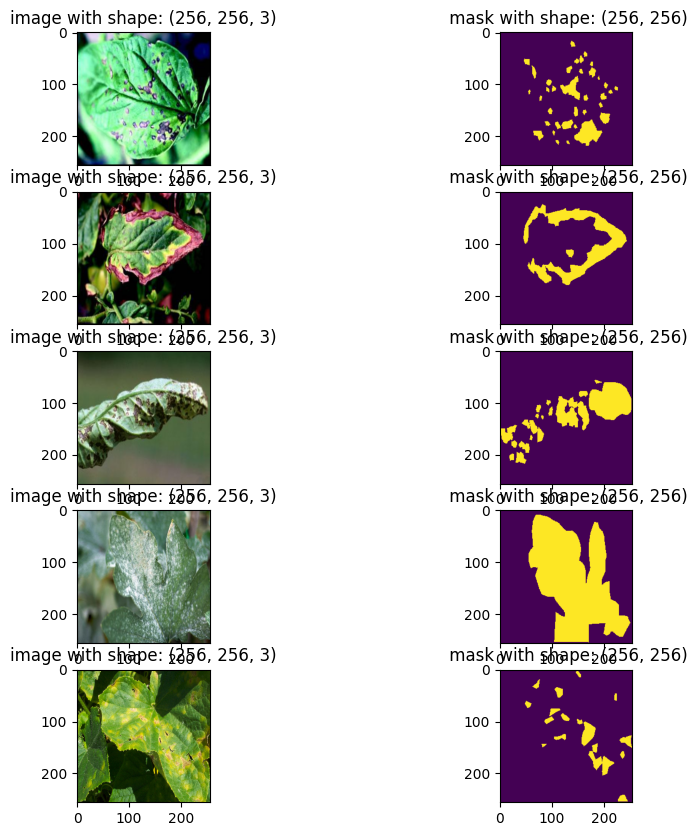

In [ ]:
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

for i in range(5):
  axs[i,0].set_title(f'image with shape: {images[i].shape}')
  axs[i,0].imshow(images[i])

  axs[i,1].set_title(f' mask with shape: {masks[i].shape}')
  axs[i,1].imshow(masks[i])
plt.show()

In [ ]:
class DataSet():
  def __init__(self, images, masks, transform = None, mask_transforms = None):
    """
    Inputs:
      images - array of images
      masks - array of true masks for images
      transform - torchvision.transforms object for image preprocessing
    """
    self.image = images
    self.mask = masks
    self.transform = transform
    self.mask_transforms = mask_transforms

  def __getitem__(self, index):
      image = self.image[index]
      mask = self.mask[index]

      if self.transform:
          image = self.transform(image)
      if self.mask_transforms:
          mask = self.mask_transforms(mask)

      return image, mask


  def __len__(self):
    return len(self.image)

In [ ]:
X_train, X_res, y_train, y_res = train_test_split(images, masks, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_res, y_res, test_size=0.1, random_state=42)


DATA_MEANS = (X_train / 255.0).mean(axis=(0, 1, 2))
DATA_STD = (X_train / 255.0).std(axis=(0, 1, 2))

print(f'train size: {len(X_train)} test size: {len(X_test)} val size: {len(X_val)} ')

train size: 470 test size: 12 val size: 106 


In [ ]:
resize = (256,256)

transform = transforms.Compose([
    transforms.ToPILImage(),
    # transforms.RandomVerticalFlip(),
    # transforms.RandomRotation(30),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATA_MEANS, std=DATA_STD)
])
transform_mask = transforms.Compose([
    transforms.ToPILImage(),
    #transforms.RandomVerticalFlip(),
    #transforms.RandomRotation(30),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),

])


In [ ]:
masks_sum = (masks==1).sum()
masks_all = np.shape(masks)[0]*256*256
print(masks_all/masks_sum)

6.080928785036199


In [ ]:
train_dataset = DataSet(X_train,
                        y_train,
                        transform,
                        transform_mask
                        )

val_dataset = DataSet(X_val,
                        y_val,
                        transform,
                        transform_mask
                      )
test_dataset = DataSet(X_test,
                        y_test,
                        transform,
                        transform_mask
                      )

In [ ]:
BATCH_SIZE = 8
patience = 10
num_epochs = 25
learning_rate = 0.0003
pos_weight = torch.tensor([masks_all/masks_sum])

In [ ]:
NUM_WORKERS = os.cpu_count()


train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

val_dataloader = DataLoader(dataset = val_dataset,
                            batch_size = 1,
                            shuffle = False,
                            num_workers = NUM_WORKERS)

test_dataloader = DataLoader(dataset = test_dataset,
                            batch_size = 1,
                            shuffle = False,
                            num_workers = NUM_WORKERS)

In [ ]:
len(train_dataloader)

59

In [ ]:
def check_accuracy(loader, model, device="cuda"):
    num_correct = 0
    num_pixels  = 0
    dice_score  = 0

    with torch.no_grad():
        for img, mask in tqdm(loader):
            img   = img.to(device)
            mask  = mask.to(device)#.unsqueeze(1)
            preds = torch.sigmoid(model(img))
            preds = (preds > 0.5).float()
            #print(preds.sum())
            num_correct += (preds == mask).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * mask).sum()) / (
                (preds + mask).sum() + 1e-7
            )

    print(
        f"Got {num_correct}/{num_pixels} with pixel accuracy {num_correct/num_pixels:.2f}"
    )
    print(f"Dice score: {dice_score/len(loader)*100:.2f}")
    return num_correct/num_pixels

In [ ]:
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.layers import trunc_normal_, DropPath

# from mmcv_custom import load_checkpoint
# from mmseg.utils import get_root_logger
# from mmseg.models.builder import BACKBONES

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:

class LayerNorm(nn.Module):
    r""" LayerNorm that supports two data formats: channels_last (default) or channels_first.
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs
    with shape (batch_size, channels, height, width).
    """
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x


In [ ]:
class Block(nn.Module):
    r""" ConvNeXt Block. There are two equivalent implementations:
    (1) DwConv -> LayerNorm (channels_first) -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W)
    (2) DwConv -> Permute to (N, H, W, C); LayerNorm (channels_last) -> Linear -> GELU -> Linear; Permute back
    We use (2) as we find it slightly faster in PyTorch

    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
    """
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim) # depthwise conv
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim) # pointwise/1x1 convs, implemented with linear layers
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1) # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2) # (N, H, W, C) -> (N, C, H, W)

        x = input + self.drop_path(x)
        return x

In [ ]:
class ConvNeXt(nn.Module):
    r"""
    Args:
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        depths (tuple(int)): Number of blocks at each stage. Default: [3, 3, 9, 3]
        dims (int): Feature dimension at each stage. Default: [96, 192, 384, 768]
        drop_path_rate (float): Stochastic depth rate. Default: 0.
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
        head_init_scale (float): Init scaling value for classifier weights and biases. Default: 1.
    """
    def __init__(self, in_chans=3, depths=[3, 3, 9, 3], dims=[96, 192, 384, 768],
                 drop_path_rate=0., layer_scale_init_value=1e-6, out_indices=[0, 1, 2, 3],
                 ):
        super().__init__()

        self.downsample_layers = nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first")
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                    LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = nn.ModuleList() # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates=[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[Block(dim=dims[i], drop_path=dp_rates[cur + j],
                layer_scale_init_value=layer_scale_init_value) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.out_indices = out_indices

        norm_layer = partial(LayerNorm, eps=1e-6, data_format="channels_first")
        for i_layer in range(4):
            layer = norm_layer(dims[i_layer])
            layer_name = f'norm{i_layer}'
            self.add_module(layer_name, layer)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=.02)
            nn.init.constant_(m.bias, 0)

    def init_weights(self, pretrained=None):
        """Initialize the weights in backbone.
        Args:
            pretrained (str, optional): Path to pre-trained weights.
                Defaults to None.
        """

        def _init_weights(m):
            if isinstance(m, nn.Linear):
                trunc_normal_(m.weight, std=.02)
                if isinstance(m, nn.Linear) and m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.bias, 0)
                nn.init.constant_(m.weight, 1.0)

        # if isinstance(pretrained, str):
        #     self.apply(_init_weights)
        #     logger = get_root_logger()
        #     load_checkpoint(self, pretrained, strict=False, logger=logger)
        # elif pretrained is None:
        #     self.apply(_init_weights)
        # else:
        #     raise TypeError('pretrained must be a str or None')

    def forward_features(self, x):
        outs = []
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
            if i in self.out_indices:
                norm_layer = getattr(self, f'norm{i}')
                x_out = norm_layer(x)
                outs.append(x_out)
        return outs

    def forward(self, x):
        outs = self.forward_features(x)

        return outs


In [ ]:
class ConvBnAct(nn.Module):

    def __init__(self, in_channel, out_channel, kernel, stride, padding, dilation=1, bias=False, act=True):
        super(ConvBnAct, self).__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel, stride, padding=padding, dilation=dilation, bias=bias)
        self.bn = nn.BatchNorm2d(out_channel)
        self.act = nn.ReLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

    def forward_fuse(self, x):
        return self.act(self.conv(x))

In [ ]:
class FeaturePyramidNet(nn.Module):

    def __init__(self, fpn_dim=256):
        self.fpn_dim = fpn_dim
        super(FeaturePyramidNet, self).__init__()
        self.fpn_in = nn.ModuleDict({'fpn_layer1': ConvBnAct(128 , self.fpn_dim, 1, 1, 0),
                                     "fpn_layer2": ConvBnAct(256 , self.fpn_dim, 1, 1, 0),
                                     "fpn_layer3": ConvBnAct(512, self.fpn_dim, 1, 1, 0),
                                    })
        self.fpn_out = nn.ModuleDict({'fpn_layer1': ConvBnAct(self.fpn_dim, self.fpn_dim, 3, 1, 1),
                                      "fpn_layer2": ConvBnAct(self.fpn_dim, self.fpn_dim, 3, 1, 1),
                                      "fpn_layer3": ConvBnAct(self.fpn_dim, self.fpn_dim, 3, 1, 1),
                                      })

    def forward(self, pyramid_features):
        """

        """
        fpn_out = {}

        f = pyramid_features[3]
        fpn_out['fpn_layer4'] = f
        x = self.fpn_in['fpn_layer3'](pyramid_features[2])
        f = F.interpolate(f, x.shape[2:], mode='bilinear', align_corners=False)
        f = x + f
        fpn_out['fpn_layer3'] = self.fpn_out['fpn_layer3'](f)

        x = self.fpn_in['fpn_layer2'](pyramid_features[1])
        f = F.interpolate(f, x.shape[2:], mode='bilinear', align_corners=False)
        f = x + f
        fpn_out['fpn_layer2'] = self.fpn_out['fpn_layer2'](f)

        x = self.fpn_in['fpn_layer1'](pyramid_features[0])
        f = F.interpolate(f, x.shape[2:], mode='bilinear', align_corners=False)
        f = x + f
        fpn_out['fpn_layer1'] = self.fpn_out['fpn_layer1'](f)

        return fpn_out

In [ ]:
class PyramidPoolingModule(nn.Module):

    def __init__(self, in_channels, out_channels, **kwargs) -> None:
        super(PyramidPoolingModule, self).__init__()
        inter_channels = in_channels //4
        self.cba1 = ConvBnAct(in_channels, inter_channels, 1, 1, 0)
        self.cba2 = ConvBnAct(in_channels, inter_channels, 1, 1, 0)
        self.cba3 = ConvBnAct(in_channels, inter_channels, 1, 1, 0)
        self.cba4 = ConvBnAct(in_channels, inter_channels, 1, 1, 0)
        self.out  = ConvBnAct(in_channels * 2, out_channels, 1, 1, 0)

    def pool(self, x, size):
        return nn.AdaptiveAvgPool2d(size)(x)

    def upsample(self, x, size):
        return F.interpolate(x, size, mode="bilinear", align_corners=True)

    def forward(self, x):
        size = x.shape[2:]
        f1 = self.upsample(self.cba1(self.pool(x, 1)), size)
        f2 = self.upsample(self.cba2(self.pool(x, 2)), size)
        f3 = self.upsample(self.cba3(self.pool(x, 3)), size)
        f4 = self.upsample(self.cba4(self.pool(x, 6)), size)
        f = torch.cat([x, f1, f2, f3, f4], dim=1)
        return self.out(f)

In [ ]:
class UPerNet(nn.Module):

    def __init__(self, in_channel=3, layers=[3, 4, 6, 3], num_class=20, fpn_dim=8, backbone=ConvNeXt()):
        super(UPerNet, self).__init__()
        self.fpn_dim = fpn_dim
        self.backbone = backbone
        self.ppm = PyramidPoolingModule(1024, self.fpn_dim)
        self.fpn = FeaturePyramidNet(self.fpn_dim)
        self.fuse = ConvBnAct(fpn_dim*4, fpn_dim, 1, 1, 0)
        self.seg = nn.Sequential(ConvBnAct(fpn_dim, fpn_dim, 1, 1, 0), nn.Conv2d(fpn_dim, num_class, 1, 1, 0, bias=True))
        self.out = nn.Conv2d(num_class, num_class, 3, 1, 1)

    def forward(self, x):
        seg_size = x.shape[2:]
        resnet_features = self.backbone(x)
        ppm = self.ppm(resnet_features[3]
        resnet_features[3]=ppm
        fpn = self.fpn(resnet_features)
        out_size = fpn['fpn_layer1'].shape[2:]
        list_f = []
        list_f.append(fpn['fpn_layer1'])
        list_f.append(F.interpolate(fpn['fpn_layer2'], out_size, mode='bilinear', align_corners=False))
        list_f.append(F.interpolate(fpn['fpn_layer3'], out_size, mode='bilinear', align_corners=False))
        list_f.append(F.interpolate(fpn['fpn_layer4'], out_size, mode='bilinear', align_corners=False))
        x = self.seg(self.fuse(torch.cat(list_f, dim=1)))
        pred = self.out(F.interpolate(x, seg_size, mode='bilinear', align_corners=False))

        return pred

In [ ]:
convnext = ConvNeXt(in_chans=3,
                    depths=[3, 3, 27, 3],
                    dims=[128, 256, 512, 1024],
                    drop_path_rate=0.4,
                    layer_scale_init_value=1.0,
                    out_indices=[0, 1, 2, 3],)

if torch.cuda.is_available():
    convnext = convnext.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.AdamW(convnext.parameters(),
                        lr=learning_rate,
                        betas=(0.9, 0.999), weight_decay=0.05,)
scheduler = ReduceLROnPlateau(optimizer, 'min',patience=7)

In [ ]:
model = UPerNet(num_class=1, backbone=convnext)
if torch.cuda.is_available():
    model = model.to(device)

In [ ]:
total_step = len(train_dataloader)
total_step_test = len(val_dataloader)

best_loss = float('inf')

test_losses = []
train_losses = []
test_accuracies = []
train_accuracies = []

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        #print(np.shape(outputs))
        loss = criterion(outputs, labels)
        #print(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(scheduler.get_last_lr())
    model.eval()
    val_loss = check_accuracy(val_dataloader, model, device=device)
    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        break

[0.0003]


100%|██████████| 106/106 [00:02<00:00, 46.61it/s]

Got 5815603/6946816 with pixel accuracy 83.72
Dice score: 7.76


[0.0003]


100%|██████████| 106/106 [00:02<00:00, 46.34it/s]

...

100%|██████████| 106/106 [00:02<00:00, 40.87it/s]

Got 5817297/6946816 with pixel accuracy 83.74
Dice score: 8.43


[0.0003]


100%|██████████| 106/106 [00:02<00:00, 40.03it/s]

Got 5821205/6946816 with pixel accuracy 83.80
Dice score: 10.02


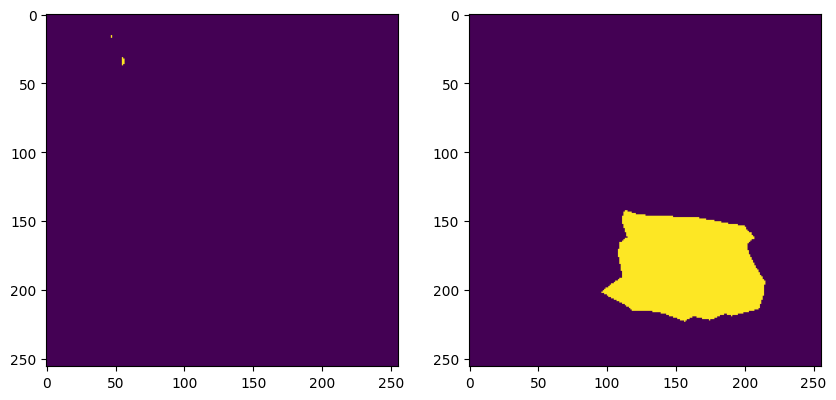

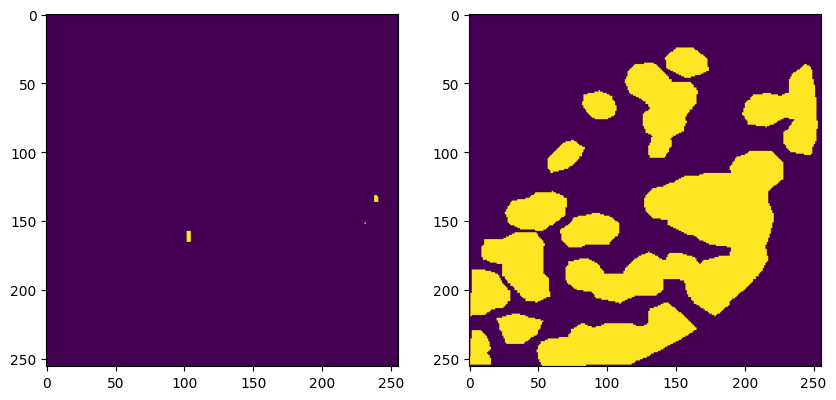

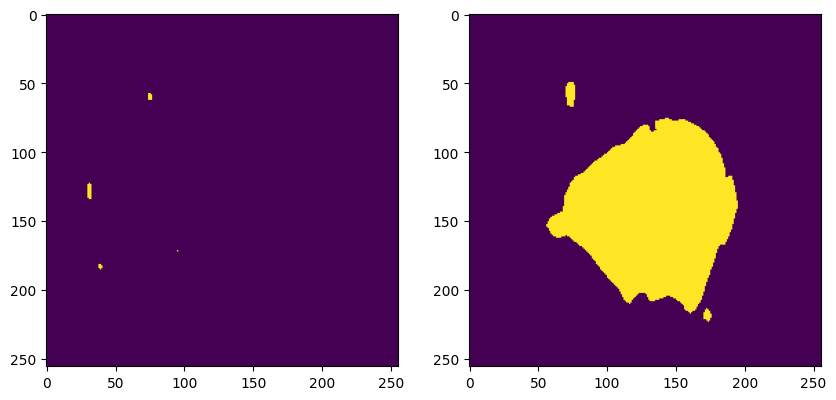

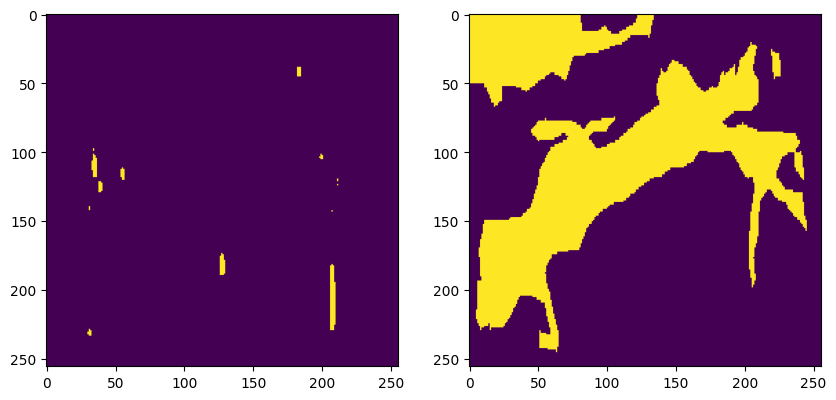

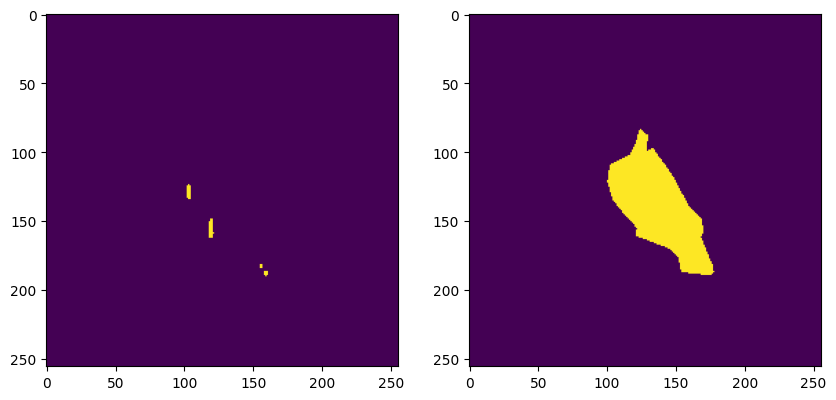

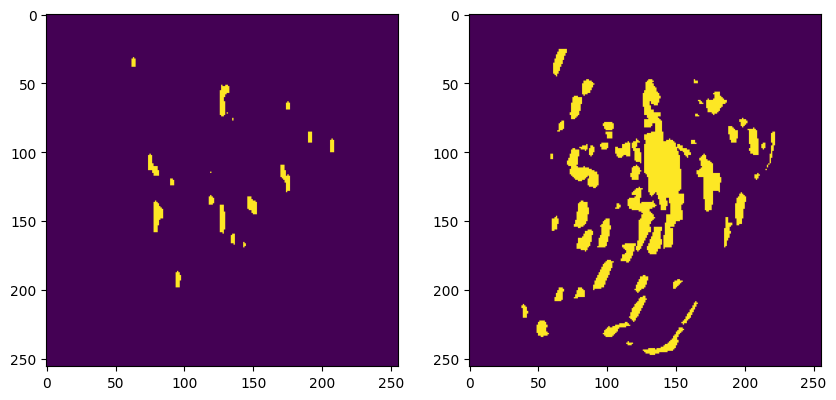

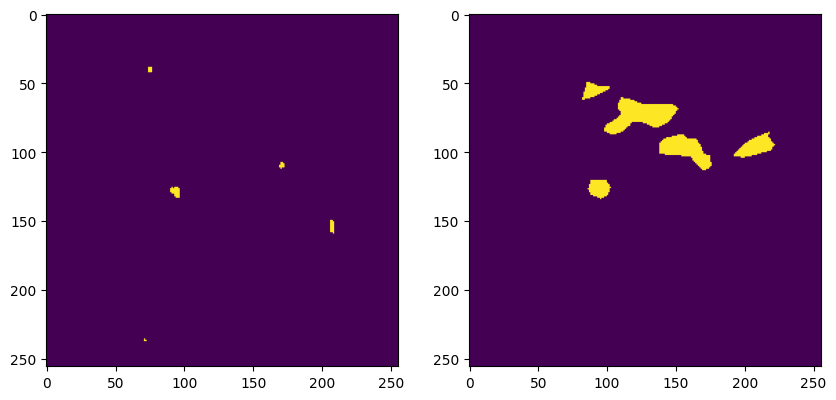

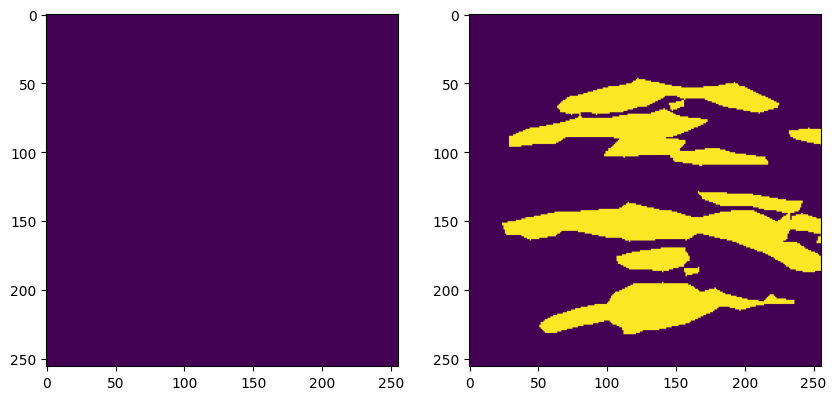

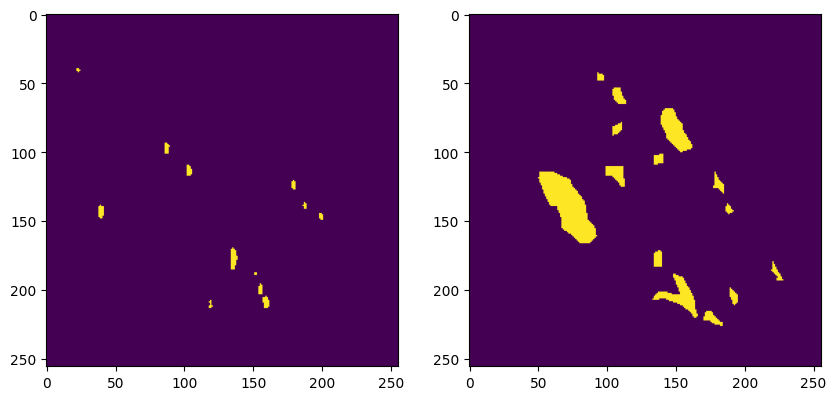

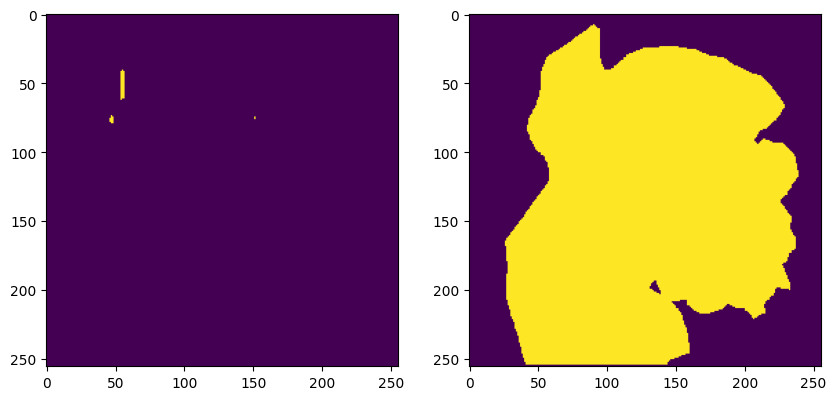

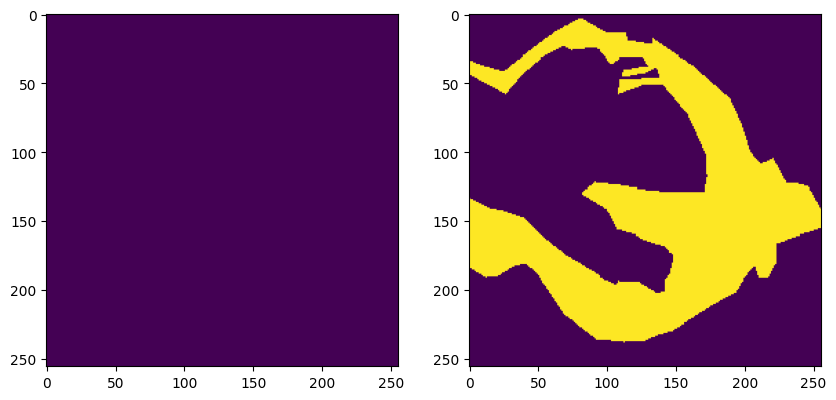

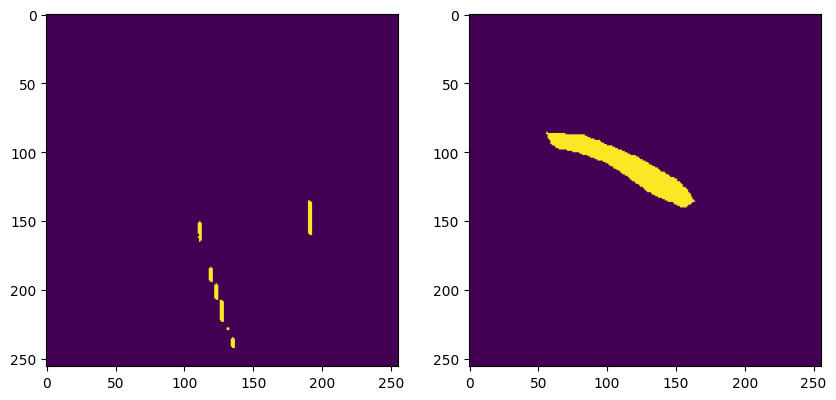

In [ ]:
model.eval()
for (images, masks) in test_dataloader:
        images = images.to(device)

        outputs = model(images)
        outputs = torch.sigmoid(torch.as_tensor(outputs[0]))
        outputs = (outputs > 0.5).float()

        outputs = outputs.to('cpu').detach().numpy()

        fig, axs = plt.subplots(1, 2, figsize=(10, 10))


        axs[0].imshow(outputs[0])
        axs[1].imshow(masks[0][0])
        plt.show()